In [ ]:
import cooler
import cooltools
from ggner_3d.boundaries import preserved_boundaries_only, make_tads, assign_domain_score
from ggner_3d.cm import prepare_view_df
import pandas as pd
import numpy as np
from coolpuppy import coolpup
from ggner_3d import plotting
plotting.update_rcparams()

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

resolution = 10_000
window = 500_000 # 500_000 or 100_000

In [ ]:
ctcf_bw = {
    'control': ['/home/carlos/Clone/ggner-3d/data/degron_pol2/bws/bw_files/GSM6245909_DLD1asyn_Ctrl_CTCF_rep1.bw',
                '/home/carlos/Clone/ggner-3d/data/degron_pol2/bws/bw_files/GSM6245910_DLD1asyn_Ctrl_CTCF_rep2.bw'],
    'degron': ['/home/carlos/Clone/ggner-3d/data/degron_pol2/bws/bw_files/GSM6245911_DLD1asyn_Aux_CTCF_rep1.bw',
               '/home/carlos/Clone/ggner-3d/data/degron_pol2/bws/bw_files/GSM6245912_DLD1asyn_Aux_CTCF_rep2.bw']
}

smc1a_bw = {
    'control': ['/home/carlos/Clone/ggner-3d/data/degron_pol2/bws/bw_files/GSM6245913_DLD1asyn_Ctrl_SMC1A_rep1.bw',
                '/home/carlos/Clone/ggner-3d/data/degron_pol2/bws/bw_files/GSM6245914_DLD1asyn_Ctrl_SMC1A_rep2.bw'],
    'degron': ['/home/carlos/Clone/ggner-3d/data/degron_pol2/bws/bw_files/GSM6245915_DLD1asyn_Aux_SMC1A_rep1.bw',
               '/home/carlos/Clone/ggner-3d/data/degron_pol2/bws/bw_files/GSM6245916_DLD1asyn_Aux_SMC1A_rep2.bw']
}

h3k27ac_bw = {
    'control': ['/home/carlos/Clone/ggner-3d/data/degron_pol2/bws/bw_files/GSM6245917_DLD1asyn_Ctrl_H3K27ac_rep1.bw'],
    'degron': ['/home/carlos/Clone/ggner-3d/data/degron_pol2/bws/bw_files/GSM6245918_DLD1asyn_Aux_H3K27ac_rep1.bw']
}

h3k27me3_bw = {
    'control': ['/home/carlos/Clone/ggner-3d/data/degron_pol2/bws/bw_files/GSM6245919_DLD1asyn_Ctrl_H3K27me3_rep1.bw',
                '/home/carlos/Clone/ggner-3d/data/degron_pol2/bws/bw_files/GSM6245920_DLD1asyn_Ctrl_H3K27me3_rep2.bw'],
    'degron': ['/home/carlos/Clone/ggner-3d/data/degron_pol2/bws/bw_files/GSM6245921_DLD1asyn_Aux_H3K27me3_rep1.bw',
               '/home/carlos/Clone/ggner-3d/data/degron_pol2/bws/bw_files/GSM6245922_DLD1asyn_Aux_H3K27me3_rep2.bw']
}

pol2_bw = {
    'control': ['/home/carlos/Clone/ggner-3d/data/degron_pol2/bws/GSM5359524_A006850091_132688_S14_L002_R1_001.nodup_x_A006850091_132684_S12_L002_R1_001.nodup.fc.signal.bigwig'],
}

In [ ]:
control_clr = cooler.Cooler(f'/home/carlos/Clone/ggner-3d/data/degron_pol2/GSM5394172_control_mergeRep_500bp.mcool::/resolutions/{resolution}')
degron_clr = cooler.Cooler(f'/home/carlos/Clone/ggner-3d/data/degron_pol2/GSM5394173_degron_mergeRep_500bp.mcool::/resolutions/{resolution}')

In [ ]:
# control_df = cooltools.insulation(
#             clr = control_clr,
#             window_bp = [window],
#             clr_weight_name='weight',
#             nproc=10
#         )

# degron_df = cooltools.insulation(
#             clr = degron_clr,
#             window_bp = [window],
#             clr_weight_name='weight',
#             nproc=10
#         )

# control_df.to_csv(f'/home/carlos/Clone/ggner-3d/data/degron_pol2/control_insulation_10kb_{window}_window.csv', index=False)
# degron_df.to_csv(f'/home/carlos/Clone/ggner-3d/data/degron_pol2/degron_insulation_10kb_{window}_window.csv', index=False)

In [ ]:
control_df = pd.read_csv(f'/home/carlos/Clone/ggner-3d/data/degron_pol2/control_insulation_10kb_{window}_window.csv')
degron_df = pd.read_csv(f'/home/carlos/Clone/ggner-3d/data/degron_pol2/degron_insulation_10kb_{window}_window.csv')

In [ ]:
def chrom_to_bin_indices(df, bins_table, bin_column = 'idx1'):
    df = df.copy()
    bins_table['indices'] = bins_table.index
    return pd.merge(df, bins_table, left_on=bin_column, right_on='indices')

insulation_table_ = [control_df, degron_df]

In [ ]:
comparisons = [(0,1)]
comparisons_str = ['control_vs_degron']
sample_names_str = ['control', 'degron']
accepted_range = 1

results, dfs = preserved_boundaries_only(
    comparisons=comparisons,
    comparisons_str=comparisons_str,
    sample_names_str=sample_names_str,
    accepted_range=accepted_range,
    insulation_table_=insulation_table_,
    window=window,
)

dfs = [
    chrom_to_bin_indices(df, control_clr.bins()[:], bin_column='idx1') for df in dfs
]

In [ ]:
common_boundaries = dfs[0].copy()
idx1_bs = control_df.iloc[common_boundaries.idx1, 7]
idx2_bs = degron_df.iloc[common_boundaries.idx2, 7]

common_boundaries['bs1'] = idx1_bs.values
common_boundaries['bs2'] = idx2_bs.values

common_boundaries['delta_bs'] = common_boundaries['bs2'] - common_boundaries['bs1']
common_boundaries['bs_Q'] = pd.qcut(common_boundaries['delta_bs'], q=4, labels=False) + 1
common_boundaries['bs_Q'].value_counts(), common_boundaries

In [ ]:
# view_df = prepare_view_df(arm=False)

# control_expected = cooltools.expected_cis(
#             clr=control_clr,
#             nproc=10,
#             view_df = view_df,
#             clr_weight_name='weight',
#         )

# degron_expected = cooltools.expected_cis(
#             clr=degron_clr,
#             nproc=10,
#             view_df = view_df,
#             clr_weight_name='weight',
#         )

# control_expected.to_csv('/home/carlos/Clone/ggner-3d/data/degron_pol2/control_expected_10kb_chrom.csv', index=False)
# degron_expected.to_csv('/home/carlos/Clone/ggner-3d/data/degron_pol2/degron_expected_10kb_chrom.csv', index=False)

control_expected = pd.read_csv('/home/carlos/Clone/ggner-3d/data/degron_pol2/control_expected_10kb_chrom.csv')
degron_expected = pd.read_csv('/home/carlos/Clone/ggner-3d/data/degron_pol2/degron_expected_10kb_chrom.csv')

In [ ]:
common_tads = make_tads(
    insul_df=dfs[0][['chrom', 'start', 'end']],
    maxlen=3e6)


In [ ]:
view_df = prepare_view_df(arm=False)

control_domain_strength = assign_domain_score(
    tads_df = common_tads,
    clr = control_clr,
    expected = control_expected,
    view_df = view_df,
    clr_weight_name='weight',
    ignore_diags=2
)

degron_domain_strength = assign_domain_score(
    tads_df = common_tads,
    clr = degron_clr,
    expected = degron_expected,
    view_df = view_df,
    clr_weight_name='weight',
    ignore_diags=2
)

In [ ]:
control_domain_df = pd.merge(common_tads, control_domain_strength, on=['chrom', 'start', 'end'])
degron_domain_df = pd.merge(common_tads, degron_domain_strength, on=['chrom', 'start', 'end'])

common_tads_ds = pd.merge(control_domain_df, degron_domain_df, on=['chrom', 'start', 'end'], suffixes=('_control', '_degron'))
common_tads_ds['delta_strength'] = common_tads_ds['domain_score_degron'] - common_tads_ds['domain_score_control']
common_tads_ds['ds_Q'] = pd.qcut(common_tads_ds['delta_strength'], q=4, labels=False) + 1
common_tads_ds['control_Q'] = pd.qcut(common_tads_ds['domain_score_control'], q=4, labels=False) + 1

eps = 1e-6
common_tads_ds['delta_strength_l2fc'] = np.log2((common_tads_ds['domain_score_degron'] + eps) / (common_tads_ds['domain_score_control'] + eps))
common_tads_ds['ds_Q_l2fc'] = pd.qcut(common_tads_ds['delta_strength_l2fc'], q=4, labels=False) + 1

In [ ]:
control_boundaries = control_df.loc[control_df[f'is_boundary_{window}'] == True]

control_tads = make_tads(
    insul_df=control_boundaries[['chrom', 'start', 'end']],
    maxlen=3e6)

In [ ]:
control_tads['length'] = control_tads['end'] - control_tads['start']
common_tads['length'] = common_tads['end'] - common_tads['start']

# viz
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(control_tads['length'], color='blue', label='Control TADs', kde=True)
sns.histplot(common_tads['length'], color='orange', label='Common TADs', kde=True)
plt.legend()

In [ ]:
view_df = prepare_view_df(arm=False)

cc = coolpup.CoordCreator(common_tads, resolution=10000, features_format='bed', local=True, rescale_flank=1)
pup_s1_tad = coolpup.PileUpper(control_clr, cc, expected=control_expected, view_df=view_df, ignore_diags=0, rescale_size=99, rescale=True, nproc=6, clr_weight_name='weight').pileupsWithControl()
pup_s2_tad = coolpup.PileUpper(degron_clr, cc, expected=degron_expected, view_df=view_df, ignore_diags=0, rescale_size=99, rescale=True, nproc=6, clr_weight_name='weight').pileupsWithControl()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(15, 5)) 

vmin = min(np.nanmin(pup_s1_tad['data'][0]), np.nanmin(pup_s2_tad['data'][0]))
vmax = max(np.nanmax(pup_s1_tad['data'][0]), np.nanmax(pup_s2_tad['data'][0]))

sns.heatmap(pup_s1_tad['data'][0], cmap='vlag', center=1, square=True, ax=axs[0], vmin=vmin, vmax=vmax)
sns.heatmap(pup_s2_tad['data'][0], cmap='vlag', center=1, square=True, ax=axs[1], vmin=vmin, vmax=vmax)
diff_mtx = pup_s2_tad['data'][0] - pup_s1_tad['data'][0]

diff_vmin = np.nanpercentile(diff_mtx, 1)
diff_vmax = np.nanpercentile(diff_mtx, 99)

sns.heatmap(diff_mtx, cmap='vlag', center=0, square=True, ax=axs[2], vmin=diff_vmin, vmax=diff_vmax)

In [ ]:
diff_mtx = pup_s2_tad['data'][0] - pup_s1_tad['data'][0]

vmin, vmax = pup_s1_tad['data'][0].min(), pup_s1_tad['data'][0].max()

aspect_ratio = 4.8
import matplotlib.pyplot as plt
from ggner_3d import plotting
import numpy as np
plotting.update_rcparams()

n_cols = 2
fig, axs = plt.subplots(1, n_cols, figsize=(n_cols*aspect_ratio, 1*aspect_ratio))
plotting.update_rcparams()

ax = plotting.hic_upper_triangle(
    pup_s1_tad['data'][0],
    cmap="vlag",
    center=1,
    ax=axs[0],
    colorbar=True,
    cbar_kws=dict(fraction=0.035, pad=0.02, aspect=8)
)

n = pup_s1_tad['data'][0].shape[0]
n_bins_rescaled = 99
fiveprime_bin = int(n_bins_rescaled * 0.33)
threeprime_bin = int(n_bins_rescaled * 0.66)
center_bin = int(n_bins_rescaled * 0.5)
bins = np.array([fiveprime_bin, center_bin, threeprime_bin])

ax.axis("on")
ax.set_xticks(2 * bins)
ax.set_xticklabels(["5' Prime\nBoundary", "Center", "3' Prime\nBoundary"])
ax.set_xlabel(f"Control\nn={pup_s1_tad['n'][0]}", labelpad=5)
# remove y ticks
ax.set_yticks([])
cbar = ax.figure.axes[-1]   # last axis is the colorbar
cbar.set_ylabel("Obs/Exp", labelpad=5)
plotting.despine(ax)

ax = plotting.hic_upper_triangle(
    diff_mtx,
    cmap="vlag",
    center=0,
    ax=axs[1],
    colorbar=True,
    cbar_kws=dict(fraction=0.035, pad=0.02, aspect=8),
    vmin=-0.2,
    vmax=0.2,
)

ax.axis("on")
ax.set_xticks(2 * bins)
ax.set_xticklabels(["5' Prime\nBoundary", "Center", "3' Prime\nBoundary"])
ax.set_xlabel(f"Pol2 Degraded - Control\nn={pup_s1_tad['n'][0]}", labelpad=5)
# remove y ticks
ax.set_yticks([])
ax.figure.axes[-1].set_ylabel("Δ Obs/Exp")


plotting.despine(ax)

### boundaries

In [18]:
view_df = prepare_view_df(arm=False)

boundaries_flank = 300_000

cc = coolpup.CoordCreator(common_boundaries, resolution=10000, features_format='bed', local=True, flank=boundaries_flank)
pup_s1 = coolpup.PileUpper(control_clr, cc, expected=control_expected, view_df=view_df, ignore_diags=0,  nproc=6, clr_weight_name='weight').pileupsWithControl()
pup_s2 = coolpup.PileUpper(degron_clr, cc, expected=degron_expected, view_df=view_df, ignore_diags=0, nproc=6, clr_weight_name='weight').pileupsWithControl()

INFO:coolpuppy:('chr6', 'chr6'): 144
INFO:coolpuppy:('chr5', 'chr5'): 156
INFO:coolpuppy:('chr3', 'chr3'): 166
INFO:coolpuppy:('chr4', 'chr4'): 161
INFO:coolpuppy:('chr1', 'chr1'): 200
INFO:coolpuppy:('chr2', 'chr2'): 200
INFO:coolpuppy:('chr7', 'chr7'): 130
INFO:coolpuppy:('chr9', 'chr9'): 100
INFO:coolpuppy:('chr11', 'chr11'): 123
INFO:coolpuppy:('chr10', 'chr10'): 106
INFO:coolpuppy:('chr8', 'chr8'): 120
INFO:coolpuppy:('chr14', 'chr14'): 71
INFO:coolpuppy:('chr12', 'chr12'): 113
INFO:coolpuppy:('chr13', 'chr13'): 71
INFO:coolpuppy:('chr15', 'chr15'): 83
INFO:coolpuppy:('chr16', 'chr16'): 56
INFO:coolpuppy:('chr17', 'chr17'): 61
INFO:coolpuppy:('chr19', 'chr19'): 52
INFO:coolpuppy:('chr21', 'chr21'): 22
INFO:coolpuppy:('chr22', 'chr22'): 31
INFO:coolpuppy:('chr20', 'chr20'): 62
INFO:coolpuppy:('chr18', 'chr18'): 60
INFO:coolpuppy:('chrX', 'chrX'): 102
INFO:coolpuppy:Total number of piled up windows: 2390
INFO:coolpuppy:('chr6', 'chr6'): 144
INFO:coolpuppy:('chr5', 'chr5'): 156
INFO:

<Axes: >

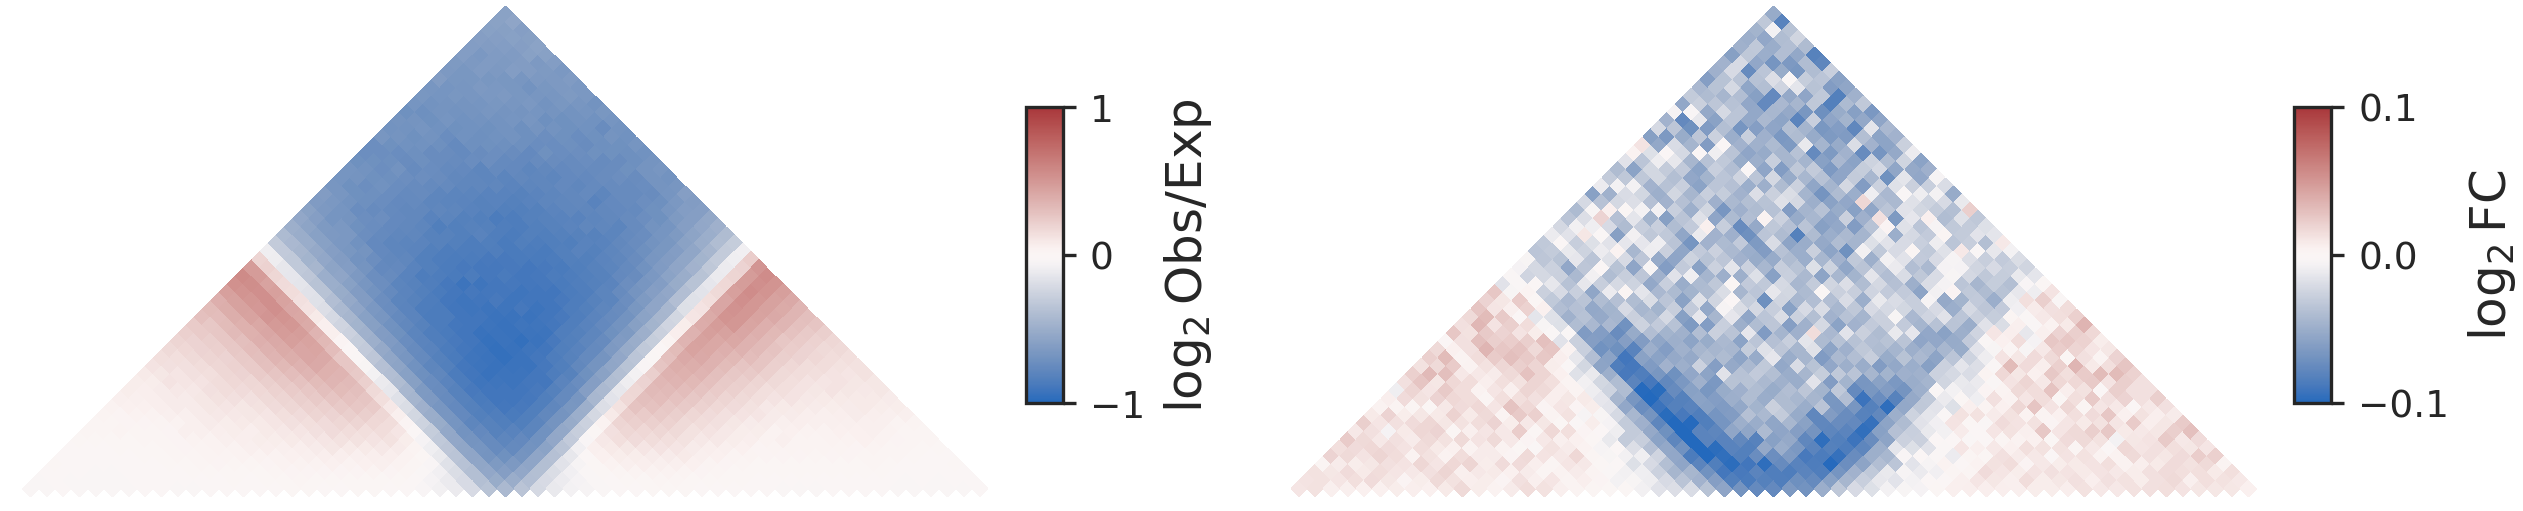

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
from ggner_3d import plotting
plotting.update_rcparams()
from ggner_3d.plotting import hic_upper_triangle

fig, axs = plt.subplots(1, 2, figsize=(10, 5)) 

mtx1 = pup_s1['data'][0]
mtx2 = pup_s2['data'][0]
eps = 1e-6
diff_l2fc = np.log2((mtx2 + eps) / (mtx1 + eps))

mtx1_l2fc = np.log2(mtx1 + eps)
mtx2_l2fc = np.log2(mtx2 + eps)

hic_upper_triangle(
    mtx1_l2fc,
    cmap="vlag",
    center=0,
    ax=axs[0],
    colorbar=True,
    cbar_kws=dict(fraction=0.035, pad=0.02, aspect=8, label=r"$\log_{2}$Obs/Exp"),
    vmin=-1, vmax=1
)

hic_upper_triangle( 
    diff_l2fc,
    cmap="vlag",
    center=0,
    ax=axs[1],
    colorbar=True,
    cbar_kws=dict(fraction=0.035, pad=0.02, aspect=8, label=r"$\log_{2}$FC"),
    vmin=-0.1, vmax=0.1
)

### Quartile Group TADs vs POL2

In [ ]:
import bbi

stack_pol2 = bbi.stackup(
        '/home/carlos/Clone/ggner-3d/data/degron_pol2/bws/GSE171910_MinusDox.PolII.bw',
        [i.replace('chr', '') for i in common_tads_ds.chrom],
        common_tads_ds.start,
        common_tads_ds.end,
        bins=1)

common_tads_ds['pol2_signal'] = stack_pol2.flatten()
common_tads_ds['pol2_Q'] = pd.qcut(common_tads_ds['pol2_signal'], q=4, labels=False) + 1
common_tads_ds

In [ ]:
flank_ratio = 0.25
nbins = 99

from ggner_3d.bbi_helpers import stackup_bw_dict
import seaborn as sns
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 5, figsize=(15, 5))

for Q in range(1, 5):
    current_tads = common_tads_ds[common_tads_ds['pol2_Q'] == Q].copy().reset_index(drop=True)
    current_tads['flank_start'] = current_tads['start'] - (current_tads['end'] - current_tads['start']) * flank_ratio
    current_tads['flank_end'] = current_tads['end'] + (current_tads['end'] - current_tads['start']) * flank_ratio
    current_tads['flank_start'] = current_tads['flank_start'].clip(lower=0)
    current_tads['flank_start'] = current_tads['flank_start'].astype(int)
    current_tads['flank_end'] = current_tads['flank_end'].astype(int)

    current_tads_adj_chrom = current_tads.copy()
    current_tads_adj_chrom['chrom'] = current_tads_adj_chrom['chrom'].apply(lambda x: x.replace('chr', ''))
    stack_pol2 = stackup_bw_dict(bw_dict=pol2_bw, df=current_tads, nbins=nbins)

    sns.lineplot(np.nanmean(stack_pol2['control'], axis=0), ax=axs[0], label=f'Q{Q}')

    stack_ctcf = stackup_bw_dict(bw_dict=ctcf_bw, df=current_tads, nbins=nbins)
    control_ctcf = stack_ctcf['control']
    degron_ctcf = stack_ctcf['degron']
    sns.lineplot(np.nanmean(control_ctcf, axis=0), ax=axs[1], label=f'Q{Q} Control')
    
    delta_ctcf = degron_ctcf - control_ctcf
    sns.lineplot(np.nanmean(delta_ctcf, axis=0), ax=axs[2], label=f'Q{Q} Degron - Control')

    stack_smc1a = stackup_bw_dict(bw_dict=smc1a_bw, df=current_tads, nbins=nbins)
    control_smc1a = stack_smc1a['control']
    degron_smc1a = stack_smc1a['degron']
    sns.lineplot(np.nanmean(control_smc1a, axis=0), ax=axs[3], label=f'Q{Q} Control')

    delta_smc1a = degron_smc1a - control_smc1a
    sns.lineplot(np.nanmean(delta_smc1a, axis=0), ax=axs[4], label=f'Q{Q} Degron - Control')

In [ ]:
quartile_pups = {
    i: [] for i in range(1, 5)
}

for i, Q in enumerate(range(1, 5)):
    current_tads = common_tads_ds[common_tads_ds['pol2_Q'] == Q][['chrom', 'start', 'end']].reset_index(drop=True)
    
    cc = coolpup.CoordCreator(current_tads, resolution=10000, features_format='bed', local=True, rescale_flank=1)
    current_pup_s1_tad = coolpup.PileUpper(control_clr, cc, expected=control_expected, view_df=view_df, ignore_diags=0, rescale_size=99, rescale=True, nproc=8, clr_weight_name='weight').pileupsWithControl()
    current_pup_s2_tad = coolpup.PileUpper(degron_clr, cc, expected=degron_expected, view_df=view_df, ignore_diags=0, rescale_size=99, rescale=True, nproc=8, clr_weight_name='weight').pileupsWithControl()

    quartile_pups[Q] = (current_pup_s1_tad, current_pup_s2_tad)

In [ ]:
fig, axs = plt.subplots(1, 4, figsize=(20, 5))
eps = 1e-6
diffs = {
        i: np.log2((quartile_pups[i][1]['data'][0] + eps) / (quartile_pups[i][0]['data'][0] + eps)) for i in common_tads_ds.ds_Q.unique()
}

vmax_diff = max(np.nanmax(diff) for diff in diffs.values())
vmin_diff = - vmax_diff

for i in range(1, 5):
    ax = axs[i-1]
    plotting.hic_upper_triangle(
        diffs[i],
        cmap="vlag",
        center=0,
        ax=ax,
        colorbar=True,
        cbar_kws=dict(fraction=0.035, pad=0.02, aspect=8, label=r"$\log_{2}$FC"),
        vmin=vmin_diff,
        vmax=vmax_diff
    )

### boundaries

In [ ]:
import bbi

flank = 200_000
nbins = 99

fig, axs = plt.subplots(2, 2, sharey='row')

for Q in range(1, 5):
    current_boundaries = common_boundaries[common_boundaries['bs_Q'] == Q].copy().reset_index(drop=True)
    current_boundaries['flank_start'] = current_boundaries['start'] - flank
    current_boundaries['flank_end'] = current_boundaries['end'] + flank
    current_boundaries['flank_start'] = current_boundaries['flank_start'].clip(lower=0)
    current_boundaries['flank_start'] = current_boundaries['flank_start'].astype(int)
    current_boundaries['flank_end'] = current_boundaries['flank_end'].astype(int)

    stack_pol2 = bbi.stackup(
        '/home/carlos/Clone/ggner-3d/data/degron_pol2/bws/GSE171910_MinusDox.PolII.bw',
        [i.replace('chr', '') for i in current_boundaries.chrom],
        current_boundaries.flank_start,
        current_boundaries.flank_end,
        bins=nbins    )

    stack_ctcf_control = bbi.stackup(
        ctcf_bw['control'][0],
        current_boundaries.chrom,
        current_boundaries.flank_start,
        current_boundaries.flank_end,
        bins=nbins
    )

    stack_ctcf_degron = bbi.stackup(
        ctcf_bw['degron'][0],
        current_boundaries.chrom,
        current_boundaries.flank_start,
        current_boundaries.flank_end,
        bins=nbins
    )

    sns.lineplot(np.nanmean(stack_pol2, axis=0), ax=axs[0,1], label=f'Q{Q}', lw=0.5)
    sns.lineplot(np.nanmean(stack_ctcf_control, axis=0), ax=axs[1,0], label=f'Q{Q}')
    sns.lineplot(np.nanmean(stack_ctcf_degron, axis=0), ax=axs[1,1], label=f'Q{Q} Degron', linestyle='--')

In [ ]:
quartile_pups = {
    i: [] for i in range(1, 5)
}

for i, Q in enumerate(range(1, 5)):
    current_boundaries = common_boundaries[common_boundaries['bs_Q'] == Q].copy().reset_index(drop=True)

    cc = coolpup.CoordCreator(current_boundaries, resolution=10000, features_format='bed', local=True, flank=flank)
    current_pup_s1_tad = coolpup.PileUpper(control_clr, cc, expected=control_expected, view_df=view_df, ignore_diags=0, nproc=8, clr_weight_name='weight').pileupsWithControl()
    current_pup_s2_tad = coolpup.PileUpper(degron_clr, cc, expected=degron_expected, view_df=view_df, rescale=True, nproc=8, clr_weight_name='weight').pileupsWithControl()

    quartile_pups[Q] = (current_pup_s1_tad, current_pup_s2_tad)

### cis decay

In [ ]:
import numpy as np

def prepare_cvd(df, max_dist=None):
    cvd = df.copy()

    # Safe assignment
    cvd.loc[cvd['dist'] < 2, 'balanced.avg.smoothed'] = np.nan
    cvd.loc[cvd['dist'] < 2, 'balanced.avg.smoothed.agg'] = np.nan

    cvd = cvd.drop_duplicates(subset=['dist'])[['dist_bp', 'balanced.avg.smoothed.agg']]

    # Filter distance range early
    if max_dist is not None:
        cvd = cvd[cvd['dist_bp'] <= max_dist]
    else:
        cvd = cvd[cvd['dist_bp'] > 0]  # Ensure we don't have zero or negative distances

    # Remove NaNs before normalization
    cvd = cvd.dropna()

    # Ensure positive values only
    cvd = cvd[cvd['balanced.avg.smoothed.agg'] > 0]
    cvd = cvd[cvd['dist_bp'] > 0]

    # Normalize by AUC
    auc = np.trapz(cvd['balanced.avg.smoothed.agg'], cvd['dist_bp'])
    if auc == 0 or not np.isfinite(auc):
        raise ValueError("AUC is zero or invalid — cannot normalize.")

    cvd['balanced.avg.smoothed.agg'] /= auc

    # Derivative in log-log space
    der = np.gradient(
        np.log(cvd['balanced.avg.smoothed.agg']),
        np.log(cvd['dist_bp'])
    )

    return cvd, der

control_clr_100kb = cooler.Cooler(f'/home/carlos/Clone/degron/GSM5394172_control_mergeRep_500bp.mcool::/resolutions/100000')
degron_clr_100kb = cooler.Cooler(f'/home/carlos/Clone/degron/GSM5394173_degron_mergeRep_500bp.mcool::/resolutions/100000')

view_df = prepare_view_df(arm=False)

control_exp_100kb = cooltools.expected_cis(
            clr=control_clr_100kb,
            nproc=10,
            view_df = view_df,
            clr_weight_name='weight',
        )

degron_exp_100kb = cooltools.expected_cis(
            clr=degron_clr_100kb,
            nproc=10,
            view_df = view_df,
            clr_weight_name='weight',
        )


In [ ]:
control_merged, control_der = prepare_cvd(control_exp_100kb, max_dist=None)
degron_merged, degron_der = prepare_cvd(degron_exp_100kb, max_dist=None)

In [ ]:
control_merged['balanced.avg.smoothed.agg'] /= control_merged['balanced.avg.smoothed.agg'].sum()
degron_merged['balanced.avg.smoothed.agg'] /= degron_merged['balanced.avg.smoothed.agg'].sum()

In [ ]:
import seaborn as sns
from matplotlib import pyplot as plt

fig, ax = plt.subplots(1,2, figsize=(16, 8))
sns.lineplot(x=control_merged['dist_bp'], y=control_merged['balanced.avg.smoothed.agg'], ax=ax[0], label='Control')
sns.lineplot(x=degron_merged['dist_bp'], y=degron_merged['balanced.avg.smoothed.agg'], ax=ax[0], label='Degron')

# set loglog
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_xlabel('Genomic Distance (bp)')
ax[0].set_ylabel('Average Contact Frequency (Obs/Exp)')
ax[0].set_title('Cis Decay Curve')
ax[0].legend()


foldchange = degron_merged['balanced.avg.smoothed.agg'] / control_merged['balanced.avg.smoothed.agg']
sns.lineplot(x=control_merged['dist_bp'], y=foldchange, ax=ax[1], label='Degron vs Control')
ax[1].set_xscale('log')
ax[1].set_xlabel('Genomic Distance (bp)')
ax[1].set_ylabel('Fold Change in Contact Frequency')
ax[1].set_title('Fold Change in Cis Decay Curve')
# add horizontal line at y=0
ax[1].axhline(1, color='gray', linestyle='--')
ax[1].legend()

plt.tight_layout()

### ctcf and cohesin

In [ ]:

from ggner_3d.bbi_helpers import stackup_bw_dict

flank_ratio = 0.25
nbins = 201

common_tads_flanked = common_tads.copy()
common_tads_flanked['length'] = common_tads_flanked['end'] - common_tads_flanked['start']
common_tads_flanked['flank_start'] = common_tads_flanked['start'] - (common_tads_flanked['length'] * flank_ratio).astype(int)
common_tads_flanked['flank_end'] = common_tads_flanked['end'] + (common_tads_flanked['length'] * flank_ratio).astype(int)

ctcf_stackup = stackup_bw_dict(
    ctcf_bw,
    common_tads_flanked,
    nbins=nbins
)
smc1a_stackup = stackup_bw_dict(
    smc1a_bw,
    common_tads_flanked,
    nbins=nbins
)
h3k27ac_stackup = stackup_bw_dict(
    h3k27ac_bw,
    common_tads_flanked,
    nbins=nbins
)
h3k27me3_stackup = stackup_bw_dict(
    h3k27me3_bw,
    common_tads_flanked,
    nbins=nbins
)
pol2_stackup = stackup_bw_dict(
    pol2_bw,
    common_tads_flanked,
    nbins=nbins
)

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
fig, ax = plt.subplots(1, 5, figsize=(32, 8))
sns.lineplot(np.nanmean(ctcf_stackup['control'], axis=0), ax=ax[0], label='Control CTCF')
sns.lineplot(np.nanmean(ctcf_stackup['degron'], axis=0), ax=ax[0], label='Degron CTCF')
sns.lineplot(np.nanmean(smc1a_stackup['control'], axis=0), ax=ax[1], label='Control SMC1A')
sns.lineplot(np.nanmean(smc1a_stackup['degron'], axis=0), ax=ax[1], label='Degron SMC1A')
sns.lineplot(np.nanmean(h3k27ac_stackup['control'], axis=0), ax=ax[2], label='Control H3K27ac')
sns.lineplot(np.nanmean(h3k27ac_stackup['degron'], axis=0), ax=ax[2], label='Degron H3K27ac')
sns.lineplot(np.nanmean(h3k27me3_stackup['control'], axis=0), ax=ax[3], label='Control H3K27me3')
sns.lineplot(np.nanmean(h3k27me3_stackup['degron'], axis=0), ax=ax[3], label='Degron H3K27me3')
sns.lineplot(np.nanmean(pol2_stackup['control'], axis=0), ax=ax[4], label='Control Pol2')

### pol2 stratified tads

In [ ]:
import bbi

pol2_signal_on_tads = bbi.stackup(
    pol2_bw['control'][0],
    common_tads.chrom,
    common_tads.start,
    common_tads.end,
    bins=1,
    summary='mean',
)

common_tads_pol2_assinged = common_tads.copy()
common_tads_pol2_assinged['pol2_signal'] = pol2_signal_on_tads
common_tads_pol2_assinged['pol2_Q'] = pd.qcut(common_tads_pol2_assinged['pol2_signal'], q=4, labels=False) + 1

In [ ]:
common_tads_pol2_assinged['length'] = common_tads_pol2_assinged['end'] - common_tads_pol2_assinged['start']
sns.histplot(common_tads_pol2_assinged, x='length', hue='pol2_Q', kde=True)

In [ ]:
common_tads_pol2_assinged_ds = pd.merge(common_tads_pol2_assinged, common_tads_ds, on=['chrom', 'start', 'end'])
sns.histplot(common_tads_pol2_assinged_ds, x='delta_strength', hue='pol2_Q', kde=True)

In [ ]:
pups_dict = {}
for q in range(1, 5):
    subset_tads = common_tads_pol2_assinged[common_tads_pol2_assinged['pol2_Q'] == q]
    view_df = prepare_view_df(arm=False)

    cc = coolpup.CoordCreator(subset_tads, resolution=10000, features_format='bed', local=True, rescale_flank=1)
    pup_s1 = coolpup.PileUpper(control_clr, cc, expected=control_expected, view_df=view_df, ignore_diags=0, rescale_size=99, rescale=True, nproc=10, clr_weight_name='weight').pileupsWithControl()
    pup_s2 = coolpup.PileUpper(degron_clr, cc, expected=degron_expected, view_df=view_df, ignore_diags=0, rescale_size=99, rescale=True, nproc=10, clr_weight_name='weight').pileupsWithControl()
    pups_dict[q] = (pup_s1, pup_s2)

In [ ]:
from ggner_3d.bbi_helpers import stackup_bw_dict

chip_data = {}
nbins = 201
flank_ratio = 0.25

for q in range(1, 5):
    current_tads_now = common_tads_pol2_assinged[common_tads_pol2_assinged['pol2_Q'] == q].copy()
    current_tads_now['length'] = current_tads_now['end'] - current_tads_now['start']
    current_tads_now['flank_start'] = current_tads_now['start'] - (current_tads_now['length'] * flank_ratio).astype(int)
    current_tads_now['flank_end'] = current_tads_now['end'] + (current_tads_now['length'] * flank_ratio).astype(int)

    ctcf_stackup = stackup_bw_dict(
        ctcf_bw,
        current_tads_now,
        nbins=nbins
    )
    smc1a_stackup = stackup_bw_dict(
        smc1a_bw,
        current_tads_now,
        nbins=nbins
    )
    h3k27ac_stackup = stackup_bw_dict(
        h3k27ac_bw,
        current_tads_now,
        nbins=nbins
    )
    h3k27me3_stackup = stackup_bw_dict(
        h3k27me3_bw,
        current_tads_now,
        nbins=nbins
    )
    pol2_stackup = stackup_bw_dict(
        pol2_bw,
        current_tads_now,
        nbins=nbins
    )
    chip_data[q] = {
        'ctcf': ctcf_stackup,
        'smc1a': smc1a_stackup,
        'h3k27ac': h3k27ac_stackup,
        'h3k27me3': h3k27me3_stackup,
        'pol2': pol2_stackup
    }

In [ ]:
fig, axs = plt.subplots(6, 4, figsize=(20, 20), sharey='row')

diff_mtx_tads = []
for q in range(1, 5):
    pup_s1, pup_s2 = pups_dict[q]
    diff = pup_s2['data'][0] - pup_s1['data'][0]
    diff_mtx_tads.append(diff)

diff_mtx_stacked = np.stack(diff_mtx_tads)
vmin = np.nanpercentile(diff_mtx_stacked, 1)
vmax = np.nanpercentile(diff_mtx_stacked, 99)

for q in range(1, 5):

    sns.heatmap(diff_mtx_tads[q-1], ax=axs[0, q-1], cmap='vlag', center=0, vmin=vmin, vmax=vmax)
    axs[0, q-1].set_title(f'Q{q} - Control')
    axs[0, q-1].set_xlabel('')
    axs[0, q-1].set_ylabel('')
    axs[0, q-1].set_xticks([])
    axs[0, q-1].set_yticks([])
    
    # ctcf
    sns.lineplot(np.nanmean(chip_data[q]['ctcf']['control'], axis=0), ax=axs[1, q-1], label='Control CTCF')
    sns.lineplot(np.nanmean(chip_data[q]['ctcf']['degron'], axis=0), ax=axs[1, q-1], label='Degron CTCF')
    axs[1, q-1].set_title(f'Q{q}')
    axs[1, q-1].set_ylabel('CTCF Signal')
    axs[1, q-1].legend()

    # smc1a
    sns.lineplot(np.nanmean(chip_data[q]['smc1a']['control'], axis=0), ax=axs[2, q-1], label='Control SMC1A')
    sns.lineplot(np.nanmean(chip_data[q]['smc1a']['degron'], axis=0), ax=axs[2, q-1], label='Degron SMC1A')
    axs[2, q-1].set_title(f'Q{q} - SMC1A')
    axs[2, q-1].set_ylabel('SMC1A Signal')
    axs[2, q-1].legend()

    # h3k27ac
    sns.lineplot(np.nanmean(chip_data[q]['h3k27ac']['control'], axis=0), ax=axs[3, q-1], label='Control H3K27ac')
    sns.lineplot(np.nanmean(chip_data[q]['h3k27ac']['degron'], axis=0), ax=axs[3, q-1], label='Degron H3K27ac')
    axs[3, q-1].set_title(f'Q{q} - H3K27ac')
    axs[3, q-1].set_ylabel('H3K27ac Signal')
    axs[3, q-1].legend()

    # h3k27me3
    sns.lineplot(np.nanmean(chip_data[q]['h3k27me3']['control'], axis=0), ax=axs[4, q-1], label='Control H3K27me3')
    sns.lineplot(np.nanmean(chip_data[q]['h3k27me3']['degron'], axis=0), ax=axs[4, q-1], label='Degron H3K27me3')
    axs[4, q-1].set_title(f'Q{q} - H3K27me3')
    axs[4, q-1].set_ylabel('H3K27me3 Signal')
    axs[4, q-1].legend()

    # pol2
    sns.lineplot(np.nanmean(chip_data[q]['pol2']['control'], axis=0), ax=axs[5, q-1], label='Control Pol2')
    axs[5, q-1].set_title(f'Q{q} - Pol2')
    axs[5, q-1].set_ylabel('Pol2 Signal')
    axs[5, q-1].legend()


### pol2 stratified boundaries

In [ ]:
import bbi

signal_flank = 20_000

pol2_signal_on_boundaries = bbi.stackup(
    pol2_bw['control'][0],
    common_boundaries.chrom,
    common_boundaries.start - signal_flank,
    common_boundaries.end + signal_flank,
    bins=1,
    summary='sum',
)

common_boundaries_pol2_assinged = common_boundaries.copy()
common_boundaries_pol2_assinged['pol2_signal'] = pol2_signal_on_boundaries
common_boundaries_pol2_assinged['pol2_Q'] = pd.qcut(common_boundaries_pol2_assinged['pol2_signal'], q=4, labels=False) + 1

In [ ]:
common_boundaries_pol2_assinged_ds = pd.merge(common_boundaries_pol2_assinged, common_boundaries, on=['chrom', 'start', 'end'])
sns.histplot(common_boundaries_pol2_assinged_ds, x='delta_bs_x', hue='pol2_Q', kde=True)

In [ ]:
boundaries_flank = 250_000

pups_dict_boundaries = {}

for q in range(1, 5):
    current_boundaries = common_boundaries_pol2_assinged[common_boundaries_pol2_assinged['pol2_Q'] == q]

    cc = coolpup.CoordCreator(current_boundaries, resolution=10000, features_format='bed', local=True, flank=boundaries_flank)
    pup_s1 = coolpup.PileUpper(control_clr, cc, expected=control_expected, view_df=view_df, ignore_diags=0,  nproc=10, clr_weight_name='weight').pileupsWithControl()
    pup_s2 = coolpup.PileUpper(degron_clr, cc, expected=degron_expected, view_df=view_df, ignore_diags=0, nproc=10, clr_weight_name='weight').pileupsWithControl()

    pups_dict_boundaries[q] = (pup_s1, pup_s2)

In [ ]:

chip_data = {}

for q in range(1, 5):
    current_boundaries_now = common_boundaries_pol2_assinged[common_boundaries_pol2_assinged['pol2_Q'] == q].copy()
    current_boundaries_now['flank_start'] = current_boundaries_now['start'] - boundaries_flank
    current_boundaries_now['flank_end'] = current_boundaries_now['end'] + boundaries_flank

    ctcf_stackup = stackup_bw_dict(
        ctcf_bw,
        current_boundaries_now,
        nbins=nbins
    )
    smc1a_stackup = stackup_bw_dict(
        smc1a_bw,
        current_boundaries_now,
        nbins=nbins
    )
    h3k27ac_stackup = stackup_bw_dict(
        h3k27ac_bw,
        current_boundaries_now,
        nbins=nbins
    )
    h3k27me3_stackup = stackup_bw_dict(
        h3k27me3_bw,
        current_boundaries_now,
        nbins=nbins
    )
    pol2_stackup = stackup_bw_dict(
        pol2_bw,
        current_boundaries_now,
        nbins=nbins
    )
    chip_data[q] = {
        'ctcf': ctcf_stackup,
        'smc1a': smc1a_stackup,
        'h3k27ac': h3k27ac_stackup,
        'h3k27me3': h3k27me3_stackup,
        'pol2': pol2_stackup
    }

In [ ]:
control_df = pd.read_csv('/home/carlos/Clone/ggner-3d/data/degron/control_insulation_10kb_500kb_window.csv')
degron_df = pd.read_csv('/home/carlos/Clone/ggner-3d/data/degron/degron_insulation_10kb_500kb_window.csv')

insul_dfs_now = [control_df, degron_df]

from ggner_3d.boundaries import get_insulation_fixed

insulation_dict = {}

for q in range(1, 5):
    current_boundaries_now = common_boundaries_pol2_assinged[common_boundaries_pol2_assinged['pol2_Q'] == q].copy()
    
    ins_array_control = get_insulation_fixed(
        insul_dfs_now[0], flank=boundaries_flank, insul_column=f'log2_insulation_score_500000', resolution=10_000, coord_df=current_boundaries_now)
    
    ins_array_degron = get_insulation_fixed(
        insul_dfs_now[1], flank=boundaries_flank, insul_column=f'log2_insulation_score_500000', resolution=10_000, coord_df=current_boundaries_now)
    
    insulation_dict[q] = {
        'control': ins_array_control,
        'degron': ins_array_degron
    }

In [ ]:
diff_mtx = []

from ggner_3d import plotting
plotting.update_rcparams()

for q in range(1, 5):
    pup_s1, pup_s2 = pups_dict_boundaries[q]
    diff = pup_s2['data'][0] - pup_s1['data'][0]
    diff_mtx.append(diff)

vmax_diff = max(np.nanmax(diff) for diff in diff_mtx)
vmin_diff = min(np.nanmin(diff) for diff in diff_mtx)

vmin_control = min(np.nanmin(pup_s1['data'][0]) for pup_s1, _ in pups_dict_boundaries.values())
vmax_control = max(np.nanmax(pup_s1['data'][0]) for pup_s1, _ in pups_dict_boundaries.values())

fig, axs = plt.subplots(9, 4, figsize=(20, 20), sharey='row')
for q in range(1, 5):
    sns.heatmap(diff_mtx[q-1], ax=axs[0, q-1], cmap='vlag', center=0, vmin=vmin_diff, vmax=vmax_diff, xticklabels=False, yticklabels=False)
    sns.heatmap(pup_s1['data'][0], ax=axs[1, q-1], cmap='vlag', center=1, vmin=vmin_control, vmax=vmax_control, xticklabels=False, yticklabels=False)
    sns.heatmap(pup_s2['data'][0], ax=axs[2, q-1], cmap='vlag', center=1, vmin=vmin_control, vmax=vmax_control, xticklabels=False, yticklabels=False)

for q in range(1, 5):
    # ctcf
    sns.lineplot(np.nanmean(chip_data[q]['ctcf']['control'], axis=0), ax=axs[3, q-1], label='Control CTCF')
    sns.lineplot(np.nanmean(chip_data[q]['ctcf']['degron'], axis=0), ax=axs[3, q-1], label='Degron CTCF')
    axs[3, q-1].set_title(f'Q{q}')
    axs[3, q-1].set_ylabel('CTCF Signal')
    axs[3, q-1].legend()

    # smc1a
    sns.lineplot(np.nanmean(chip_data[q]['smc1a']['control'], axis=0), ax=axs[4, q-1], label='Control SMC1A')
    sns.lineplot(np.nanmean(chip_data[q]['smc1a']['degron'], axis=0), ax=axs[4, q-1], label='Degron SMC1A')
    axs[4, q-1].set_title(f'Q{q} - SMC1A')
    axs[4, q-1].set_ylabel('SMC1A Signal')
    axs[4, q-1].legend()

    # h3k27ac
    sns.lineplot(np.nanmean(chip_data[q]['h3k27ac']['control'], axis=0), ax=axs[5, q-1], label='Control H3K27ac')
    sns.lineplot(np.nanmean(chip_data[q]['h3k27ac']['degron'], axis=0), ax=axs[5, q-1], label='Degron H3K27ac')
    axs[5, q-1].set_title(f'Q{q} - H3K27ac')
    axs[5, q-1].set_ylabel('H3K27ac Signal')
    axs[5, q-1].legend()

    # h3k27me3
    sns.lineplot(np.nanmean(chip_data[q]['h3k27me3']['control'], axis=0), ax=axs[6, q-1], label='Control H3K27me3')
    sns.lineplot(np.nanmean(chip_data[q]['h3k27me3']['degron'], axis=0), ax=axs[6, q-1], label='Degron H3K27me3')
    axs[6, q-1].set_title(f'Q{q} - H3K27me3')
    axs[6, q-1].set_ylabel('H3K27me3 Signal')
    axs[6, q-1].legend()

    # pol2
    sns.lineplot(np.nanmean(chip_data[q]['pol2']['control'], axis=0), ax=axs[7, q-1], label='Control Pol2')
    axs[7, q-1].set_title(f'Q{q} - Pol2')
    axs[7, q-1].set_ylabel('Pol2 Signal')
    axs[7, q-1].legend()

    # insulation

    ins_control = np.nanmean(insulation_dict[q]['control'], axis=0)
    ins_degron = np.nanmean(insulation_dict[q]['degron'], axis=0)
    ins_diff = ins_degron - ins_control

    sns.lineplot(np.nanmean(insulation_dict[q]['control'], axis=0), ax=axs[8, q-1], label='Control Insulation')
    sns.lineplot(np.nanmean(insulation_dict[q]['degron'], axis=0), ax=axs[8, q-1], label='Degron Insulation')

    # sns.lineplot(ins_diff, ax=axs[8, q-1], label='Degron - Control Insulation')

    axs[8, q-1].set_title(f'Q{q} - Insulation')
    axs[8, q-1].set_ylabel('Insulation Signal')
    axs[8, q-1].legend()

### tads stratified by domain strength

In [ ]:
pups_dict_tads = {}
for q in range(1, 5):
    subset_tads = common_tads_ds[common_tads_ds['ds_Q'] == q][['chrom', 'start', 'end']]
    view_df = prepare_view_df(arm=False)
    cc = coolpup.CoordCreator(subset_tads, resolution=10000, features_format='bed', local=True, rescale_flank=1)
    pup_s1 = coolpup.PileUpper(control_clr, cc, expected=control_expected, view_df=view_df, ignore_diags=0, rescale_size=99, rescale=True, nproc=10, clr_weight_name='weight').pileupsWithControl()
    pup_s2 = coolpup.PileUpper(degron_clr, cc, expected=degron_expected, view_df=view_df, ignore_diags=0, rescale_size=99, rescale=True, nproc=10, clr_weight_name='weight').pileupsWithControl()
    pups_dict_tads[q] = (pup_s1, pup_s2)

In [ ]:
from ggner_3d.bbi_helpers import stackup_bw_dict

chip_data = {}
nbins = 201
flank_ratio = 0.25

for q in range(1, 5):
    current_tads_now = common_tads_ds[common_tads_ds['ds_Q'] == q].copy()
    current_tads_now['length'] = current_tads_now['end'] - current_tads_now['start']
    current_tads_now['flank_start'] = current_tads_now['start'] - (current_tads_now['length'] * flank_ratio).astype(int)
    current_tads_now['flank_end'] = current_tads_now['end'] + (current_tads_now['length'] * flank_ratio).astype(int)

    ctcf_stackup = stackup_bw_dict(
        ctcf_bw,
        current_tads_now,
        nbins=nbins
    )
    smc1a_stackup = stackup_bw_dict(
        smc1a_bw,
        current_tads_now,
        nbins=nbins
    )
    h3k27ac_stackup = stackup_bw_dict(
        h3k27ac_bw,
        current_tads_now,
        nbins=nbins
    )
    h3k27me3_stackup = stackup_bw_dict(
        h3k27me3_bw,
        current_tads_now,
        nbins=nbins
    )
    pol2_stackup = stackup_bw_dict(
        pol2_bw,
        current_tads_now,
        nbins=nbins
    )
    chip_data[q] = {
        'ctcf': ctcf_stackup,
        'smc1a': smc1a_stackup,
        'h3k27ac': h3k27ac_stackup,
        'h3k27me3': h3k27me3_stackup,
        'pol2': pol2_stackup
    }

In [ ]:
diff_mtx_tads = []
for q in range(1, 5):
    pup_s1, pup_s2 = pups_dict_tads[q]
    diff = pup_s2['data'][0] - pup_s1['data'][0]
    diff_mtx_tads.append(diff)

vmin = min(np.nanmin(diff) for diff in diff_mtx_tads)
vmax = max(np.nanmax(diff) for diff in diff_mtx_tads)

fig, axs = plt.subplots(6, 4, figsize=(20, 20), sharey='row')
for q in range(1, 5):
    # sns.heatmap(diff_mtx_tads[q-1], ax=axs[0, q-1], cmap='vlag', vmin=vmin, vmax=vmax, center=0)
    
    # ctcf
    sns.lineplot(np.nanmean(chip_data[q]['ctcf']['control'], axis=0), ax=axs[1, q-1], label='Control CTCF')
    sns.lineplot(np.nanmean(chip_data[q]['ctcf']['degron'], axis=0), ax=axs[1, q-1], label='Degron CTCF')
    axs[1, q-1].set_title(f'Q{q}')
    axs[1, q-1].set_ylabel('CTCF Signal')
    axs[1, q-1].legend()

    # smc1a
    sns.lineplot(np.nanmean(chip_data[q]['smc1a']['control'], axis=0), ax=axs[2, q-1], label='Control SMC1A')
    sns.lineplot(np.nanmean(chip_data[q]['smc1a']['degron'], axis=0), ax=axs[2, q-1], label='Degron SMC1A')
    axs[2, q-1].set_title(f'Q{q} - SMC1A')
    axs[2, q-1].set_ylabel('SMC1A Signal')
    axs[2, q-1].legend()

    # h3k27ac
    sns.lineplot(np.nanmean(chip_data[q]['h3k27ac']['control'], axis=0), ax=axs[3, q-1], label='Control H3K27ac')
    sns.lineplot(np.nanmean(chip_data[q]['h3k27ac']['degron'], axis=0), ax=axs[3, q-1], label='Degron H3K27ac')
    axs[3, q-1].set_title(f'Q{q} - H3K27ac')
    axs[3, q-1].set_ylabel('H3K27ac Signal')
    axs[3, q-1].legend()

    # h3k27me3
    sns.lineplot(np.nanmean(chip_data[q]['h3k27me3']['control'], axis=0), ax=axs[4, q-1], label='Control H3K27me3')
    sns.lineplot(np.nanmean(chip_data[q]['h3k27me3']['degron'], axis=0), ax=axs[4, q-1], label='Degron H3K27me3')
    axs[4, q-1].set_title(f'Q{q} - H3K27me3')
    axs[4, q-1].set_ylabel('H3K27me3 Signal')
    axs[4, q-1].legend()

    # pol2
    sns.lineplot(np.nanmean(chip_data[q]['pol2']['control'], axis=0), ax=axs[5, q-1], label='Control Pol2')
    axs[5, q-1].set_title(f'Q{q} - Pol2')
    axs[5, q-1].set_ylabel('Pol2 Signal')
    axs[5, q-1].legend()


### boundaries stratified by boundary strength

In [ ]:
pups_dict_boundaries = {}
boundaries_flank = 250_000
for q in range(1, 5):
    current_boundaries_now = common_boundaries[common_boundaries['bs_Q'] == q].copy()
    print(f"Processing Q{q} with {len(current_boundaries_now)} boundaries")
    cc = coolpup.CoordCreator(current_boundaries_now, resolution=10000, features_format='bed', local=True, flank=boundaries_flank)
    pup_s1 = coolpup.PileUpper(control_clr, cc, expected=control_expected, view_df=view_df, ignore_diags=0,  nproc=10, clr_weight_name='weight').pileupsWithControl()
    pup_s2 = coolpup.PileUpper(degron_clr, cc, expected=degron_expected, view_df=view_df, ignore_diags=0, nproc=10, clr_weight_name='weight').pileupsWithControl()
    pups_dict_boundaries[q] = (pup_s1, pup_s2)

In [ ]:
from ggner_3d.bbi_helpers import stackup_bw_dict

chip_data = {}
nbins = 201

for q in range(1, 5):
    current_boundaries_now = common_boundaries[common_boundaries['bs_Q'] == q].copy()
    current_boundaries_now['flank_start'] = current_boundaries_now['start'] - boundaries_flank
    current_boundaries_now['flank_end'] = current_boundaries_now['end'] + boundaries_flank

    ctcf_stackup = stackup_bw_dict(
        ctcf_bw,
        current_boundaries_now,
        nbins=nbins
    )
    smc1a_stackup = stackup_bw_dict(
        smc1a_bw,
        current_boundaries_now,
        nbins=nbins
    )
    h3k27ac_stackup = stackup_bw_dict(
        h3k27ac_bw,
        current_boundaries_now,
        nbins=nbins
    )
    h3k27me3_stackup = stackup_bw_dict(
        h3k27me3_bw,
        current_boundaries_now,
        nbins=nbins
    )
    pol2_stackup = stackup_bw_dict(
        pol2_bw,
        current_boundaries_now,
        nbins=nbins
    )
    chip_data[q] = {
        'ctcf': ctcf_stackup,
        'smc1a': smc1a_stackup,
        'h3k27ac': h3k27ac_stackup,
        'h3k27me3': h3k27me3_stackup,
        'pol2': pol2_stackup
    }

In [ ]:
diff_mtx_boundaries = []
for q in range(1, 5):
    pup_s1, pup_s2 = pups_dict_boundaries[q]
    diff = pup_s2['data'][0] - pup_s1['data'][0]
    diff_mtx_boundaries.append(diff)

vmin = min(np.nanmin(diff) for diff in diff_mtx_boundaries)
vmax = max(np.nanmax(diff) for diff in diff_mtx_boundaries)

fig, axs = plt.subplots(6, 4, figsize=(20, 20), sharey='row')
for q in range(1, 5):
    # sns.heatmap(diff_mtx_boundaries[q-1], ax=axs[0, q-1], cmap='vlag', vmin=vmin, vmax=vmax, center=0)
    
    # ctcf
    sns.lineplot(np.nanmean(chip_data[q]['ctcf']['control'], axis=0), ax=axs[1, q-1], label='Control CTCF')
    sns.lineplot(np.nanmean(chip_data[q]['ctcf']['degron'], axis=0), ax=axs[1, q-1], label='Degron CTCF')
    axs[1, q-1].set_title(f'Q{q}')
    axs[1, q-1].set_ylabel('CTCF Signal')
    axs[1, q-1].legend()

    # smc1a
    sns.lineplot(np.nanmean(chip_data[q]['smc1a']['control'], axis=0), ax=axs[2, q-1], label='Control SMC1A')
    sns.lineplot(np.nanmean(chip_data[q]['smc1a']['degron'], axis=0), ax=axs[2, q-1], label='Degron SMC1A')
    axs[2, q-1].set_title(f'Q{q} - SMC1A')
    axs[2, q-1].set_ylabel('SMC1A Signal')
    axs[2, q-1].legend()

    # h3k27ac
    sns.lineplot(np.nanmean(chip_data[q]['h3k27ac']['control'], axis=0), ax=axs[3, q-1], label='Control H3K27ac')
    sns.lineplot(np.nanmean(chip_data[q]['h3k27ac']['degron'], axis=0), ax=axs[3, q-1], label='Degron H3K27ac')
    axs[3, q-1].set_title(f'Q{q} - H3K27ac')
    axs[3, q-1].set_ylabel('H3K27ac Signal')
    axs[3, q-1].legend()

    # h3k27me3
    sns.lineplot(np.nanmean(chip_data[q]['h3k27me3']['control'], axis=0), ax=axs[4, q-1], label='Control H3K27me3')
    sns.lineplot(np.nanmean(chip_data[q]['h3k27me3']['degron'], axis=0), ax=axs[4, q-1], label='Degron H3K27me3')
    axs[4, q-1].set_title(f'Q{q} - H3K27me3')
    axs[4, q-1].set_ylabel('H3K27me3 Signal')
    axs[4, q-1].legend()

    # pol2
    sns.lineplot(np.nanmean(chip_data[q]['pol2']['control'], axis=0), ax=axs[5, q-1], label='Control Pol2')
    axs[5, q-1].set_title(f'Q{q} - Pol2')
    axs[5, q-1].set_ylabel('Pol2 Signal')
    axs[5, q-1].legend()


### tad 2 tad interactions

In [ ]:
import numpy as np
import pandas as pd
import cooler


def scaled_balanced_cool_dump(
    clr,
    *,
    target_sum=1e6,
    dump_path=None,
    field_name="scaled",
    cis_only=True,              # <<< NEW ARG
    include_bad_bins_as_nan=True,
):
    """
    Dump a cooler where pixel values are balanced interactions scaled
    so their total sum equals `target_sum`.

    Scaling modes:
        cis_only=True   → scale using only cis pixels
        cis_only=False  → scale using cis + trans pixels

    scaled_value = balanced * (target_sum / sum(balanced_selected))
    """

    bins = clr.bins()[:]
    chroms = clr.chromnames

    # -------------------------------------------------------
    # PASS 1: compute total balanced sum (selected pixels)
    # -------------------------------------------------------

    total = 0.0

    if cis_only:
        # sum per chromosome (cis only)
        for chrom in chroms:
            pix = clr.matrix(balance=True, as_pixels=True, join=False).fetch(chrom)
            if pix.empty:
                continue

            bal = pix["balanced"].to_numpy()
            good = np.isfinite(bal)
            if np.any(good):
                total += float(np.nansum(bal[good]))

    else:
        # full matrix including trans
        pix = clr.matrix(balance=True, as_pixels=True, join=False)[:]
        bal = pix["balanced"].to_numpy()
        good = np.isfinite(bal)
        if np.any(good):
            total = float(np.nansum(bal[good]))

    if not np.isfinite(total) or total <= 0:
        raise ValueError(f"Total balanced sum is {total}. Check balancing or region selection.")

    scale = float(target_sum) / total

    # -------------------------------------------------------
    # PASS 2: create scaled pixel dataframe
    # -------------------------------------------------------

    out_chunks = []

    if cis_only:
        for chrom in chroms:
            pix = clr.matrix(balance=True, as_pixels=True, join=False).fetch(chrom)
            if pix.empty:
                continue

            scaled = pix["balanced"].to_numpy() * scale

            chunk = pix[["bin1_id", "bin2_id"]].copy()
            chunk[field_name] = scaled.astype(np.float64)
            out_chunks.append(chunk)

    else:
        pix = clr.matrix(balance=True, as_pixels=True, join=False)[:]
        scaled = pix["balanced"].to_numpy() * scale

        chunk = pix[["bin1_id", "bin2_id"]].copy()
        chunk[field_name] = scaled.astype(np.float64)
        out_chunks.append(chunk)

    res_df = pd.concat(out_chunks, ignore_index=True)

    # -------------------------------------------------------
    # Optional dump
    # -------------------------------------------------------

    if dump_path is not None:
        bins_out = bins.copy()

        if include_bad_bins_as_nan and "weight" in bins_out.columns:
            bad = bins_out["weight"].isna()
            bins_out["weight"] = 1.0
            bins_out.loc[bad, "weight"] = np.nan

        print(f"Scaling mode: {'cis-only' if cis_only else 'cis+trans'}")
        print(f"Scaling factor = {scale:.6g} (sum -> {target_sum})")
        print(f"Dumping to {dump_path} ...")

        cooler.create_cooler(
            cool_uri=dump_path,
            bins=bins_out,
            pixels=res_df,
            columns=[field_name],
            dtypes={field_name: np.float64},
        )

    return res_df, scale

def scaled_balanced_cool_dump_streaming(
    clr,
    *,
    target_sum=1e6,
    dump_path=None,
    field_name="scaled",
    cis_only=True,
    include_bad_bins_as_nan=True,
    weight_name="weight",
    divisive_weights=None,   # match cooler.matrix() behavior
    chunksize=1_000_000,
    return_pixels=False,     # if True, returns a generator instead of building a giant DF
):
    """
    Memory-efficient version:
      - Reads pixels in chunks from clr.pixels()
      - Computes balanced = count * w1*w2 (or divisive if requested)
      - Scales so sum(balanced_selected) == target_sum
      - Optionally writes a new cooler using a chunk iterator

    Notes:
      - create_cooler() supports iterable/generator of DataFrame chunks. :contentReference[oaicite:1]{index=1}
      - pixels() returns a 1D range selector you can slice. :contentReference[oaicite:2]{index=2}
    """
    bins = clr.bins()[:]

    # Load weights (small; bins table is typically manageable)
    if weight_name in bins.columns:
        w = bins[weight_name].to_numpy(np.float64)
    else:
        w = np.ones(len(bins), dtype=np.float64)

    # Mirror cooler.matrix() default: weights are multiplicative unless named KR/VC/SQRT_VC. :contentReference[oaicite:3]{index=3}
    if divisive_weights is None:
        divisive = weight_name in {"KR", "VC", "SQRT_VC"}
    else:
        divisive = bool(divisive_weights)

    # Fast cis mask via chromosome codes per bin
    chrom_codes = pd.Categorical(bins["chrom"]).codes.astype(np.int32)

    # nnz is a core metadata field for coolers (fallback: len(pixels)). :contentReference[oaicite:4]{index=4}
    nnz = int(clr.info.get("nnz", 0)) or len(clr.pixels(join=False))

    pixsel = clr.pixels(join=False)

    def _balanced_from_chunk(df):
        b1 = df["bin1_id"].to_numpy(np.int64, copy=False)
        b2 = df["bin2_id"].to_numpy(np.int64, copy=False)
        cnt = df["count"].to_numpy(np.float64, copy=False)

        pair_w = w[b1] * w[b2]

        if divisive:
            bal = np.empty_like(cnt, dtype=np.float64)
            ok = np.isfinite(pair_w) & (pair_w != 0)
            np.divide(cnt, pair_w, out=bal, where=ok)
            bal[~ok] = np.nan
        else:
            bal = cnt * pair_w  # NaNs propagate automatically if any weight is NaN

        if cis_only:
            mask = chrom_codes[b1] == chrom_codes[b2]
            return b1[mask], b2[mask], bal[mask]
        else:
            return b1, b2, bal

    # --------------------------
    # PASS 1: compute total sum
    # --------------------------
    total = 0.0
    for lo in range(0, nnz, chunksize):
        hi = min(lo + chunksize, nnz)
        df = pixsel[lo:hi]  # slice -> DataFrame
        _, _, bal = _balanced_from_chunk(df)
        total += float(np.nansum(bal))

    if not np.isfinite(total) or total <= 0:
        raise ValueError(f"Total balanced sum is {total}. Check weights / selection.")

    scale = float(target_sum) / total

    # --------------------------
    # PASS 2: stream scaled pixels
    # --------------------------
    def pixels_iter():
        for lo in range(0, nnz, chunksize):
            hi = min(lo + chunksize, nnz)
            df = pixsel[lo:hi]
            b1, b2, bal = _balanced_from_chunk(df)

            out = pd.DataFrame(
                {
                    "bin1_id": b1,
                    "bin2_id": b2,
                    field_name: (bal * scale).astype(np.float64),
                }
            )
            yield out

    # Optional dump (streaming write)
    if dump_path is not None:
        bins_out = bins.copy()
        if include_bad_bins_as_nan and weight_name in bins_out.columns:
            bad = bins_out[weight_name].isna()
            bins_out[weight_name] = 1.0
            bins_out.loc[bad, weight_name] = np.nan

        cooler.create_cooler(
            cool_uri=dump_path,
            bins=bins_out,
            pixels=pixels_iter(),          # iterable of chunks :contentReference[oaicite:5]{index=5}
            columns=[field_name],
            dtypes={field_name: np.float64},
            ordered=True,                  # chunks already in pixel-table order :contentReference[oaicite:6]{index=6}
            symmetric_upper=(clr.storage_mode == "symmetric-upper"),
        )

    if return_pixels:
        return pixels_iter(), scale

    return None, scale

def genomewide_full_tad2tad_from_pixel_field(
    clr: cooler.Cooler,
    tads_df: pd.DataFrame,
    *,
    field: str = "scaled",      # pixel field to aggregate (e.g., "scaled" or "oe")
    agg: str = "mean",          # "mean" or "sum" within each TAD×TAD block
    ignore_diagonal: int = 0,   # drop pixels with dist_bins < ignore_diagonal
    symmetrize: bool = True,    # mirror upper triangle to lower
    return_per_chrom: bool = True,  # if True, also return per-chrom matrices
):
    """
    Build FULL cis TAD×TAD matrices from a cooler pixel field, and optionally a single
    genome-wide block-diagonal matrix.

    This is appropriate when your cooler already contains the quantity you want to aggregate
    (e.g., an O/E field 'oe' or a scaled balanced field 'scaled').

    Notes
    -----
    - This is cis-only by construction (we fetch per chromosome).
    - 'sum' means sum of the *field values* inside each TAD block.
      For scaled balanced fields this is often meaningful; for OE, 'mean' is usually preferred.

    Returns
    -------
    G : np.ndarray
        Genome-wide block-diagonal TAD×TAD matrix (total_TADs × total_TADs)
    meta : dict
        chrom_order, offsets, sizes, tads_by_chrom
    per_chrom : dict (optional)
        per_chrom[chrom] = {"matrix": M, "tads": tads_chr}
    """

    if agg not in {"mean", "sum"}:
        raise ValueError("agg must be 'mean' or 'sum'")
    if ignore_diagonal < 0:
        raise ValueError("ignore_diagonal must be >= 0")

    bins = clr.bins()[:]  # indexed by global bin_id
    chroms = list(bins["chrom"].unique())

    tads = tads_df[["chrom", "start", "end"]].copy()
    tads = tads.sort_values(["chrom", "start", "end"]).reset_index(drop=True)

    def tad_map_for_chrom(bins_chr: pd.DataFrame, tads_chr: pd.DataFrame):
        """Map each bin midpoint to a TAD id (0..n_tads-1) or -1 if outside."""
        tads_chr = tads_chr.sort_values(["start", "end"]).reset_index(drop=True)
        mid = ((bins_chr["start"].to_numpy() + bins_chr["end"].to_numpy()) // 2).astype(np.int64)
        starts = tads_chr["start"].to_numpy(np.int64)
        ends = tads_chr["end"].to_numpy(np.int64)

        idx = np.searchsorted(starts, mid, side="right") - 1
        ok = (idx >= 0) & (mid < ends[idx])
        out = np.full(len(mid), -1, dtype=np.int32)
        out[ok] = idx[ok]
        return out, tads_chr

    per_chrom = {}
    sizes = {}
    tads_by_chrom = {}

    for chrom in chroms:
        tads_chr = tads[tads["chrom"] == chrom]
        if tads_chr.empty:
            continue

        bins_chr = bins[bins["chrom"] == chrom]
        if bins_chr.empty:
            continue

        tad_map, tads_chr = tad_map_for_chrom(bins_chr, tads_chr)
        n_tads = len(tads_chr)
        if n_tads == 0:
            continue

        # cis pixels for this chromosome
        pix = clr.matrix(field=field, as_pixels=True, join=False).fetch(chrom)
        if pix.empty:
            continue

        # upper triangle + dist (as column, stays aligned)
        pix = pix[pix["bin2_id"] >= pix["bin1_id"]].copy()
        pix["dist_bins"] = (pix["bin2_id"] - pix["bin1_id"]).astype(np.int64)

        if ignore_diagonal > 0:
            pix = pix[pix["dist_bins"] >= ignore_diagonal].copy()
            if pix.empty:
                continue

        # map global bin_id -> local index within chrom to index tad_map
        bin_ids_chr = bins_chr.index.to_numpy()
        local_index = pd.Series(np.arange(len(bin_ids_chr)), index=bin_ids_chr)

        b1_local = local_index.loc[pix["bin1_id"]].to_numpy()
        b2_local = local_index.loc[pix["bin2_id"]].to_numpy()

        pix["tad1"] = tad_map[b1_local]
        pix["tad2"] = tad_map[b2_local]
        pix = pix[(pix["tad1"] >= 0) & (pix["tad2"] >= 0)].copy()
        if pix.empty:
            continue

        v = pix[field].to_numpy()
        good = np.isfinite(v)
        if not np.any(good):
            continue

        tad1 = pix["tad1"].to_numpy()[good]
        tad2 = pix["tad2"].to_numpy()[good]
        v = v[good]

        # aggregate pixels -> FULL per-chrom TAD×TAD matrix
        g = pd.DataFrame({"tad1": tad1, "tad2": tad2, "v": v})
        if agg == "mean":
            gb = g.groupby(["tad1", "tad2"], sort=False)["v"].mean().reset_index()
        else:
            gb = g.groupby(["tad1", "tad2"], sort=False)["v"].sum().reset_index()

        M = np.full((n_tads, n_tads), np.nan, dtype=float)
        M[gb["tad1"].to_numpy(), gb["tad2"].to_numpy()] = gb["v"].to_numpy()

        if symmetrize:
            M = np.where(np.isnan(M), M.T, M)

        per_chrom[chrom] = {"matrix": M, "tads": tads_chr}
        sizes[chrom] = n_tads
        tads_by_chrom[chrom] = tads_chr

    # genome-wide block diagonal
    chrom_order = [c for c in chroms if c in per_chrom]
    total = int(sum(sizes[c] for c in chrom_order))
    G = np.full((total, total), np.nan, dtype=float)

    offsets = {}
    cur = 0
    for c in chrom_order:
        offsets[c] = cur
        n = sizes[c]
        G[cur:cur + n, cur:cur + n] = per_chrom[c]["matrix"]
        cur += n

    meta = {
        "field": field,
        "agg": agg,
        "ignore_diagonal": ignore_diagonal,
        "chrom_order": chrom_order,
        "offsets": offsets,
        "sizes": sizes,
        "tads_by_chrom": tads_by_chrom,
    }

    if return_per_chrom:
        return G, meta, per_chrom
    return G, meta

In [ ]:
resolution = 10_000

control_clr = cooler.Cooler(f'/home/carlos/Clone/degron/GSM5394172_control_mergeRep_500bp.mcool::/resolutions/{resolution}')
degron_clr = cooler.Cooler(f'/home/carlos/Clone/degron/GSM5394173_degron_mergeRep_500bp.mcool::/resolutions/{resolution}')

scaled_pixels_t0, scale_t0 = scaled_balanced_cool_dump_streaming(
    control_clr,
    target_sum=1e6,
    dump_path=f"/home/carlos/Clone/ggner-3d/data/degron/control_scaled_1e6_cis_{resolution}.cool",
    field_name="scaled",
    cis_only=True,
)

scaled_pixels_t12, scale_t12 = scaled_balanced_cool_dump_streaming(
    degron_clr,
    target_sum=1e6,
    dump_path=f"/home/carlos/Clone/ggner-3d/data/degron/degron_scaled_1e6_cis_{resolution}.cool",
    field_name="scaled",
    cis_only=True,
)

In [ ]:
resolution = 10_000
control_clr_scaled = cooler.Cooler(f"/home/carlos/Clone/ggner-3d/data/degron/control_scaled_1e6_cis_{resolution}.cool")
degron_clr_scaled = cooler.Cooler(f"/home/carlos/Clone/ggner-3d/data/degron/degron_scaled_1e6_cis_{resolution}.cool")

In [ ]:
tads_df_sorted = common_tads.sort_values(["chrom", "start", "end"]).reset_index(drop=True)

tads_df_sorted = tads_df_sorted.loc[tads_df_sorted.chrom == 'chr1']

from ggner_3d.cm import genomewide_full_tad2tad_from_pixel_field
G0, meta0, per0 = genomewide_full_tad2tad_from_pixel_field(
    control_clr_scaled,
    tads_df_sorted,
    field="scaled",
    agg="sum",
    ignore_diagonal=2,
)

G12, meta12, per12 = genomewide_full_tad2tad_from_pixel_field(
    degron_clr_scaled,
    tads_df_sorted,
    field="scaled",
    agg="sum",
    ignore_diagonal=2,
)

In [ ]:
mask_n_diag = -1

G0_masked = G0.copy()
G12_masked = G12.copy()

if mask_n_diag >= 0:
    for i in range(-mask_n_diag, mask_n_diag + 1):
        np.fill_diagonal(G0_masked[max(0, i):, max(0, -i):], np.nan)
        np.fill_diagonal(G12_masked[max(0, i):, max(0, -i):], np.nan)

diff_mtx = G12_masked - G0_masked
tad2tad_scores = np.nanmean(diff_mtx, axis=0)

tads_df_sorted['t2t_score'] = tad2tad_scores
tads_df_sorted['t2t_score_Q'] = pd.qcut(tads_df_sorted['t2t_score'], q=4, labels=False) + 1

In [ ]:
pol2_bw = '/home/carlos/Clone/ggner-3d/data/degron/bws/GSM5359524_A006850091_132688_S14_L002_R1_001.nodup_x_A006850091_132684_S12_L002_R1_001.nodup.fc.signal.bigwig'

import bbi

stack = bbi.stackup(pol2_bw, tads_df_sorted.chrom, tads_df_sorted.start, tads_df_sorted.end, bins=1).flatten()

fig, ax = plt.subplots(1,2, figsize=(12, 6))
sns.heatmap(diff_mtx, ax=ax[0], cmap='vlag', center=0)
sns.lineplot(stack, ax=ax[1])

In [ ]:
pups_dict_tads = {}

control_clr = cooler.Cooler(f'/home/carlos/Clone/degron/GSM5394172_control_mergeRep_500bp.mcool::/resolutions/{resolution}')
degron_clr = cooler.Cooler(f'/home/carlos/Clone/degron/GSM5394173_degron_mergeRep_500bp.mcool::/resolutions/{resolution}')

for q in range(1, 5):
    subset_tads = tads_df_sorted[tads_df_sorted['t2t_score_Q'] == q][['chrom', 'start', 'end']]
    view_df = prepare_view_df(arm=False)
    cc = coolpup.CoordCreator(subset_tads, resolution=10000, features_format='bed', local=True, rescale_flank=1)
    pup_s1 = coolpup.PileUpper(control_clr, cc, expected=control_expected, view_df=view_df, ignore_diags=0, rescale_size=99, rescale=True, nproc=4, clr_weight_name='weight').pileupsWithControl()
    pup_s2 = coolpup.PileUpper(degron_clr, cc, expected=degron_expected, view_df=view_df, ignore_diags=0, rescale_size=99, rescale=True, nproc=4, clr_weight_name='weight').pileupsWithControl()
    pups_dict_tads[q] = (pup_s1, pup_s2)

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(3, 4, figsize=(20, 15))

diff_mtx_tads = []
for q in range(1, 5):
    pup_s1, pup_s2 = pups_dict_tads[q]
    diff = pup_s2['data'][0] - pup_s1['data'][0]
    diff_mtx_tads.append(diff)

diff_vmin = min(np.nanmin(diff) for diff in diff_mtx_tads)
diff_vmax = max(np.nanmax(diff) for diff in diff_mtx_tads)

vmin_control = min(np.nanmin(pup_s1['data'][0]) for pup_s1, _ in pups_dict_tads.values())
vmax_control = max(np.nanmax(pup_s1['data'][0]) for pup_s1, _ in pups_dict_tads.values())

for q in range(1, 5):
    sns.heatmap(diff_mtx_tads[q-1], ax=axs[0, q-1], cmap='vlag', vmin=diff_vmin, vmax=diff_vmax, center=0)
    axs[0, q-1].set_title(f'Q{q} - TAD×TAD Difference (Degron - Control)')

    sns.heatmap(pups_dict_tads[q][0]['data'][0], ax=axs[1, q-1], cmap='vlag', vmin=vmin_control, vmax=vmax_control, center=1)
    axs[1, q-1].set_title(f'Q{q} - Control TAD Pileup')

    sns.heatmap(pups_dict_tads[q][1]['data'][0], ax=axs[2, q-1], cmap='vlag', vmin=vmin_control, vmax=vmax_control, center=1)
    axs[2, q-1].set_title(f'Q{q} - Degron TAD Pileup')

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

show_chrom = "chr1"
off = meta0["offsets"][show_chrom]
n = meta0["sizes"][show_chrom]

# use meta0 consistently (assumes same TADs used for both)
chrom_G0  = G0[off:off+n, off:off+n].copy()
chrom_G12 = G12[off:off+n, off:off+n].copy()

# mask near diagonal for visualization

mask_n_diag = 0

if mask_n_diag >= 0:
    for i in range(-mask_n_diag, mask_n_diag + 1):
        np.fill_diagonal(chrom_G0[max(0, i):, max(0, -i):], np.nan)
        np.fill_diagonal(chrom_G12[max(0, i):, max(0, -i):], np.nan)

# shared color limits for t0/t12
vmin = np.nanmin(np.stack([chrom_G0, chrom_G12]))
vmax = np.nanmax(np.stack([chrom_G0, chrom_G12]))

fig, axs = plt.subplots(1, 3, figsize=(12, 5))

sns.heatmap(chrom_G0, ax=axs[0], cmap="Reds", vmin=vmin, vmax=vmax)
axs[0].set_title(f"{show_chrom} TAD×TAD scaled interactions\nTimepoint: NoUV")

sns.heatmap(chrom_G12, ax=axs[1], cmap="Reds", vmin=vmin, vmax=vmax)
axs[1].set_title(f"{show_chrom} TAD×TAD scaled interactions\nTimepoint: 12 mins PostUV")

diff_mtx = chrom_G12 - chrom_G0
diff_mtx_abs = np.abs(diff_mtx)
diff_mtx_sign = np.sign(diff_mtx)

diff_mtx = diff_mtx_abs * vmax
diff_mtx *= diff_mtx_sign

sns.heatmap(diff_mtx, ax=axs[2], cmap="vlag", center=0)
axs[2].set_title(f"{show_chrom} TAD×TAD scaled interactions\nDifference (12 mins - NoUV)")

plt.tight_layout()
plt.show()

In [ ]:
k=2

G0_c = G0.copy()
G0_c[G0_c == 0] = np.nan
G12_c = G12.copy()
G12_c[G12_c == 0] = np.nan

G0_c += np.nanmin([G12_c, G0_c])
G12_c += np.nanmin([G12_c, G0_c])

diff = G12_c - G0_c
diff_upper = np.triu(diff, k=k)
diff_upper[diff_upper == 0] = np.nan
diff_upper = np.log1p(diff_upper)

sns.heatmap(diff_upper, cmap="vlag", center=0)

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


def plot_genomewide_tad2tad_t0_t12_delta(
    G0,
    G12,
    meta,
    *,
    ignore_diagonal: int = 2,
    raw_cmap: str = "Reds",
    delta_cmap: str = "vlag",
    q_raw: float = 0.995,     # robust upper limit for raw (0..q)
    q_delta: float = 0.99,    # robust symmetric limit for delta
    delta_mode: str = "log2fc",  # "log2fc" or "diff"
    show_chrom_separators: bool = True,
    separator_lw: float = 0.4,
    figsize=(18, 6),
):
    """
    Genome-wide block-diagonal viz for full TAD×TAD matrices.

    - t0/t12 shown on RAW scale (no log2)
    - delta shown as either:
        - log2fc: log2(G12/G0) centered at 0 (recommended)
        - diff:   G12 - G0 centered at 0
    - Masks near diagonal |i-j| < ignore_diagonal for visualization.

    meta must contain: chrom_order, offsets, sizes
    """
    eps = 1e-12
    n = G0.shape[0]
    if G12.shape != G0.shape:
        raise ValueError("G0 and G12 must have same shape")

    # copies so we don't modify originals
    A0 = G0.copy()
    A12 = G12.copy()

    # mask near diagonal
    if ignore_diagonal and ignore_diagonal > 0:
        ii, jj = np.indices((n, n))
        near = (np.abs(ii - jj) < ignore_diagonal)
        A0[near] = np.nan
        A12[near] = np.nan

    # shared raw color limits (0 .. robust vmax)
    vmax_raw = np.nanquantile(np.stack([A0, A12]), q_raw)
    vmin_raw = 0.0

    # delta
    if delta_mode == "log2fc":
        D = np.log2(np.maximum(A12, eps)) - np.log2(np.maximum(A0, eps))
        cbar_delta = "log2 fold-change (t12/t0)"
    elif delta_mode == "diff":
        D = A12 - A0
        cbar_delta = "difference (t12 - t0)"
    else:
        raise ValueError("delta_mode must be 'log2fc' or 'diff'")

    vmax_d = np.nanquantile(np.abs(D), q_delta)
    if not np.isfinite(vmax_d) or vmax_d <= 0:
        vmax_d = 1.0

    fig, axs = plt.subplots(1, 3, figsize=figsize, constrained_layout=True)

    sns.heatmap(
        A0, ax=axs[0], cmap=raw_cmap, vmin=vmin_raw, vmax=vmax_raw,
        square=True, cbar_kws={"label": "raw (t0)"}
    )
    axs[0].set_title("Genome-wide TAD×TAD (t0)")
    axs[0].set_xlabel("Genome-wide TAD index")
    axs[0].set_ylabel("Genome-wide TAD index")

    sns.heatmap(
        A12, ax=axs[1], cmap=raw_cmap, vmin=vmin_raw, vmax=vmax_raw,
        square=True, cbar_kws={"label": "raw (t12)"}
    )
    axs[1].set_title("Genome-wide TAD×TAD (t12)")
    axs[1].set_xlabel("Genome-wide TAD index")
    axs[1].set_ylabel("Genome-wide TAD index")

    sns.heatmap(
        D, ax=axs[2], cmap=delta_cmap, center=0, vmin=-vmax_d, vmax=vmax_d,
        square=True, cbar_kws={"label": cbar_delta}
    )
    axs[2].set_title("Genome-wide TAD×TAD (delta)")
    axs[2].set_xlabel("Genome-wide TAD index")
    axs[2].set_ylabel("Genome-wide TAD index")

    # chromosome separators
    if show_chrom_separators:
        boundaries = [meta["offsets"][c] for c in meta["chrom_order"]]
        last = meta["chrom_order"][-1]
        boundaries.append(meta["offsets"][last] + meta["sizes"][last])
        boundaries = [b for b in boundaries if b not in (0, n)]

        for ax in axs:
            for b in boundaries:
                ax.axhline(b, color="black", lw=separator_lw)
                ax.axvline(b, color="black", lw=separator_lw)

    return fig, axs


# ---- Example ----
fig, axs = plot_genomewide_tad2tad_t0_t12_delta(
    G0, G12, meta0,
    ignore_diagonal=-1,
    raw_cmap="Reds",
    delta_cmap="vlag",
    delta_mode="diff",
)
plt.show()

### compartments

In [ ]:
view_df = prepare_view_df(arm=False)
import os
resolution = 100_000
gc_path = '/home/carlos/Clone/ggner-3d/data/compartment/hg38_gc_cov_100kb.tsv'
gc_cov = pd.read_csv(gc_path, sep='\t')
import multiprocess as mp
pool = mp.Pool(6)

control_clr = cooler.Cooler(f'/home/carlos/Clone/ggner-3d/data/degron_pol2/GSM5394172_control_mergeRep_500bp.mcool::/resolutions/{resolution}')
degron_clr = cooler.Cooler(f'/home/carlos/Clone/ggner-3d/data/degron_pol2/GSM5394173_degron_mergeRep_500bp.mcool::/resolutions/{resolution}')

_, eigvec_table_control = cooltools.eigs_cis(
    clr=control_clr,
    phasing_track=gc_cov,
    view_df=view_df,
    n_eigs=3,
    clr_weight_name='weight',
    sort_metric='MAD_explained',
    map=pool.map
)

_, eigvec_table_degron = cooltools.eigs_cis(
    clr=degron_clr,
    phasing_track=gc_cov,
    view_df=view_df,
    n_eigs=3,
    clr_weight_name='weight',
    sort_metric='MAD_explained',
    map=pool.map
)

In [ ]:
control_expected = cooltools.expected_cis(
            clr=control_clr,
            nproc=10,
            view_df = view_df,
            clr_weight_name='weight',
        )

degron_expected = cooltools.expected_cis(
            clr=degron_clr,
            nproc=10,
            view_df = view_df,
            clr_weight_name='weight',
        )

In [ ]:
# import pearson corr
from scipy.stats import pearsonr

e1_control = eigvec_table_control['E1'].to_numpy()
e1_degron = eigvec_table_degron['E1'].to_numpy()
not_na_mask = np.isfinite(e1_control) & np.isfinite(e1_degron)
corr, pval = pearsonr(e1_control[not_na_mask], e1_degron[not_na_mask])
print(f"Pearson correlation of E1 between control and degron: {corr:.4f} (p={pval:.2e})")

In [ ]:
eigenvector_track_control = eigvec_table_control[['chrom','start','end','E1']]
eigenvector_track_degron = eigvec_table_degron[['chrom','start','end','E1']]

N_GROUPS = 50
Q_LO, Q_HI = 0.025, 0.975
max_diag = int(10_000_000 // resolution)

interaction_sum_c, interaction_count_c =  cooltools.saddle(
        control_clr,
        control_expected,
        eigenvector_track_control,
        'cis',
        n_bins=N_GROUPS,
        qrange=(Q_LO,Q_HI),
        view_df=view_df,
        max_diag=max_diag
)

interaction_sum_d, interaction_count_d =  cooltools.saddle(
        degron_clr,
        degron_expected,
        eigenvector_track_degron,
        'cis',
        n_bins=N_GROUPS,
        qrange=(Q_LO,Q_HI),
        view_df=view_df,
        max_diag=max_diag
)

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

vmin = np.nanmin(interaction_sum_c / interaction_count_c)
vmax = np.nanmax(interaction_sum_c / interaction_count_c)

sns.heatmap(interaction_sum_c / interaction_count_c, cmap='vlag', center=1, ax=axs[0], vmin=vmin, vmax=vmax, square=True)
axs[0].set_title('Control Saddle Plot (E1)')
sns.heatmap(interaction_sum_d / interaction_count_d, cmap='vlag', center=1, ax=axs[1], vmin=vmin, vmax=vmax, square=True)
axs[1].set_title('Degron Saddle Plot (E1)')

delta = (interaction_sum_d / interaction_count_d) - (interaction_sum_c / interaction_count_c)
sns.heatmap(delta, cmap='vlag', center=0, ax=axs[2], square=True)
axs[2].set_title('Delta Saddle Plot (Degron - Control)')

In [ ]:
from cooltools.api.saddle import saddle_strength

saddle_c = (interaction_sum_c, interaction_count_c)
saddle_d = (interaction_sum_d, interaction_count_d)

for name, saddle in [('Control', saddle_c), ('Degron', saddle_d)]:
    x = np.arange(N_GROUPS + 2)

    plt.step(x, np.log2(saddle_strength(saddle[0], saddle[1])), where='pre', label=name)

    plt.xlabel('extent')
    plt.ylabel('log2 (AA + BB) / (AB + BA)')
    plt.title('saddle strength profile')
    plt.axhline(0, c='grey', ls='--', lw=1)

plt.legend()